# Procurement Research Agent

A multi-agent AI system for defense procurement research built with LangGraph and Ollama. Given a procurement topic, three specialized agents collaborate to search for market data, analyze findings, and draft a structured recommendation.

**Agents:**
- Research Agent: searches the web for supplier and pricing information
- Analysis Agent: extracts key findings from search results
- Recommendation Agent: synthesizes findings into a procurement recommendation

**Stack:** LangGraph / LangChain / Ollama (Mistral) / Tavily Search API

**Pipeline:**
1. User submits a procurement research topic
2. Research Agent searches web via Tavily
3. Analysis Agent processes search results
4. Recommendation Agent drafts final recommendation
5. Output returned with full reasoning chain visible

## Environment and Imports

In [ ]:
# Standard libraries
import os
from typing import TypedDict, Annotated
import operator
import pandas as pd
import matplotlib.pyplot as plt
# Environment variables
from dotenv import load_dotenv
load_dotenv()
# LangChain
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
# LangGraph
from langgraph.graph import StateGraph, END
# Tavily search
from tavily import TavilyClient
# Verify API key loaded
tavily_key = os.getenv("TAVILY_API_KEY")
print(f"Tavily API key loaded: {'Yes' if tavily_key else 'No not found'}")

Tavily API key loaded: Yes


## State

State is the shared object that gets passed between agents at each step. Every agent reads from it and writes its output back to it.

Think of it like a baton in a relay race: each agent picks it up, does its work, adds its findings, and passes it to the next agent.

**Our state tracks:**
- topic: the original procurement research topic from the user
- search_results: raw results returned by Tavily
- analysis: key findings extracted by the Analysis Agent
- recommendation: final procurement recommendation
- messages: full message history for transparency

In [ ]:
class ProcurementState(TypedDict):
    topic: str # original user query
    search_results: str # raw Tavily search results
    analysis: str # Analysis Agent findings
    recommendation: str # final recommendation
    messages: Annotated[list, operator.add] # running message log

## Initialize LLM and Tools

**LLM:** Ollama/Mistral running locally  
**Tool:** Tavily Search API: purpose-built for LLM applications, returns clean summarized search results rather than raw HTML. Free tier gives 1000 searches/month, plenty for development.

temperature=0.1 keeps agents focused and factual. Procurement recommendations benefit from slightly more flexible language generation.

In [3]:
# initialize LLM
llm = ChatOllama(
    model='mistral',
    temperature=0.1
)
# initalize Tavily search client
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
# test both are working
print("LLM Test..")
test_response = llm.invoke([HumanMessage(content="reply with one word: ready")])
print(f"LLM Response: {test_response.content.strip()}")

print("\nTavily Test..")
test_search = tavily.search("defense procurement market trends", max_results=1)
print(f"Tavily Response: {test_search['results'][0]['title']}")

LLM Test..
LLM Response: Affirmative.

Tavily Test..
Tavily Response: Defense Procurement Market Size, Trends, and Forecast | Growth Outlook & Industry Analysis - 2033


## Build the Agents

Each agent is a Python function that:
1. Receives the current state
2. Does its specific job
3. Returns a dictionary updating the state

**Research Agent**: calls Tavily to search the web  
**Analysis Agent**: reads search results, extracts key findings  
**Recommendation Agent**: synthesizes analysis into a procurement recommendation

In LangGraph these functions become nodes in a graph. The edges between nodes define the execution order.

In [4]:
# Research Agent
def research_agent(state: ProcurementState) -> dict:
    """
    Searches the web for information on the procurement topic.
    Uses Tavily to return clean, LLM-ready search results
    """
    topic = state['topic']
    print(f"Research Agent search: {topic}")
    # search Tavily. max_results=5 balances coverage vs context length
    results = tavily.search(
        query=f"defense procurement {topic} suppliers pricing market data",
        max_results=5
    )
    # format results into clean text for the next agent
    formatted = ""
    for i, r in enumerate(results['results']):
        formatted += f"\nSource {i+1}: {r['title']}\n"
        formatted += f"URL: {r['url']}\n"
        formatted += f"Summary: {r['content']}\n"
        formatted += '-'*42

    print(f"  Found {len(results['results'])} sources")

    return {
        "search_results":formatted,
        "messages":[AIMessage(content=f"Research Agent: found {len(results['results'])} sources for '{topic}'")]
    }

In [5]:
# Analysis Agent
def analysis_agent(state: ProcurementState) -> dict:
    """
    Reads raw search results and extracts key findings relevant to a procurement decision.
    """
    print("Analysis Agent processing search results..")
    prompt = f"""
    You are a defense procurement analyst. Analyze the following search results about: {state['topic']}

    Search Results:
    {state['search_results']}

    Extract and summarize the following:
    1. Key suppliers or vendors identified
    2. Pricing trends or cost data mentioned
    3. Market conditions relevant to procurement
    4. Any risks or considerations for a defense buyer
    5. Data gaps - what important information was NOT found

    Be specific and cite sources where possible. Be concise.
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    analysis = response.content
    print("  Analysis complete")

    return {
        "analysis":analysis,
        "messages":[AIMessage(content=f"Analysis Agent: completed analysis of search results")]
    }

In [6]:
# Recommendation Agent
def recommendation_agent(state: ProcurementState) -> dict:
    """
    Synthesizes the analysis into a structured procurement recommendation formatted for a defense acquisition professional.
    """
    print("Recommendation Agent drafting recommendation..")
    prompt = f"""
    You are a senior defense procurement advisor. Based on the following analysis, draft a structured procurement recommendation.

    Procurement Topic: {state['topic']}

    Analysis Findings:
    {state['analysis']}

    Format your recommendation as follows:

    ## Procurement Recommendation: {state['topic']}

    ### Executive Summary
    [2-3 sentence summary of the recommendation]

    ### Market Assessment
    [Key findings about suppliers and market conditions]

    ### Cost Considerations
    [Pricing trends and budget implications]

    ### Risks and Mitigations
    [Key risks and how to address them]

    ### Recommended Next Steps
    [Specific actionable steps for the procurement team]

    ### Information Gaps
    [What additional research is needed before final decision]
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    recommendation = response.content
    print("  Recommendation drafted")

    return {
        "recommendation":recommendation,
        "messages":[AIMessage(content="Recommendation Agent: procurement recommendation complete")]
    }

## Build the LangGraph

LangGraph organizes agents as nodes in a directed graph. Edges define the execution order, which agent runs after which.

This graph is a simple linear chain:  
Research Agent -> Analysis Agent -> Recommendation Agent -> END

More complex graphs can have:
- Conditional edges (different paths based on agent output)
- Cycles (agents that loop until a condition is met)
- Parallel nodes (multiple agents running simultaneously)

In [7]:
# initialize the graph with the state definition
workflow = StateGraph(ProcurementState)
# add agents as nodes
workflow.add_node("research",research_agent)
workflow.add_node("analysis",analysis_agent)
workflow.add_node("recommendation",recommendation_agent)
# define edges/execution order
workflow.set_entry_point("research")
workflow.add_edge("research","analysis")
workflow.add_edge("analysis","recommendation")
workflow.add_edge("recommendation",END)
# compile into a runnable
agent = workflow.compile()

## Run the Agent

Test the full multi-agent pipeline with a real procurement topic. Each agent's print statement shows the execution flow in real time.

In [8]:
# define procurement research topic relevant to defense/aviation
topic = "helicopter rotor blade components suppliers and pricing"

print('-'*42)
print(f"PROCUREMENT RESEARCH AGENT")
print(f"Topic: {topic}")
print('-'*42)
# run the full agent pipeline
result = agent.invoke({
    "topic":topic,
    "search_results":"",
    "analysis":"",
    "recommendation":"",
    "messages":[HumanMessage(content=topic)]
})
print()
print('-'*42)
print("FINAL RECOMMENDATION")
print('-'*42)
print(result['recommendation'])

------------------------------------------
PROCUREMENT RESEARCH AGENT
Topic: helicopter rotor blade components suppliers and pricing
------------------------------------------
Research Agent search: helicopter rotor blade components suppliers and pricing
  Found 5 sources
Analysis Agent processing search results..
  Analysis complete
Recommendation Agent drafting recommendation..
  Recommendation drafted

------------------------------------------
FINAL RECOMMENDATION
------------------------------------------
 ## Procurement Recommendation: helicopter rotor blade components suppliers and pricing

### Executive Summary
The defense procurement team should consider engaging with key helicopter rotor blade component suppliers such as Airbus, Sikorsky, and Leonardo due to the growing Helicopter Blades Market, which is projected to reach USD 1.62 billion by 2031 and $3.9 billion by 2034.

### Market Assessment
Key suppliers identified include Airbus, Sikorsky, and Leonardo. The market for h

## Inspect the State

In [9]:
print("----- FULL STATE INSPECTION -----")
print("\n--- TOPIC ---")
print(result['topic'])
print("\n--- SEARCH RESULTS (first 500 chars) ---")
print(result['search_results'][:500])
print("\n--- ANALYSIS (first 500 chars) ---")
print(result['analysis'][:500])
print("\n--- MESSAGE LOG ---")
for msg in result['messages']:
    print(f"  {msg.__class__.__name__}: {msg.content}")

----- FULL STATE INSPECTION -----

--- TOPIC ---
helicopter rotor blade components suppliers and pricing

--- SEARCH RESULTS (first 500 chars) ---

Source 1: Helicopter Blades Market - Size, Share & Forecast
URL: https://www.mordorintelligence.com/industry-reports/helicopter-blades-market
Summary: The Helicopter Blades Market worth USD 1.32 billion in 2026 is growing at a CAGR of 4.56% to reach USD 1.62 billion by 2031.
------------------------------------------
Source 2: Helicopter Rotor Blades Market Research Report 2034
URL: https://dataintelo.com/report/global-helicopter-rotor-blades-market
Summary: * Helicopter Rotor Blades Market Res

--- ANALYSIS (first 500 chars) ---
 1. Key suppliers or vendors identified:
   - Airbus (Source 5)
   - Sikorsky (Source 5)
   - Leonardo (Source 5)
   - No specific pricing data was provided for these companies, but the market reports suggest a growing and expanding market (Sources 1 & 2).

2. Pricing trends or cost data mentioned:
   - The Helicop

## Multi-Topic Test

Run the agent across multiple procurement topics to demonstrate the system works generically, not just for one hardcoded query. This also stress-tests the pipeline and surfaces any edge cases.

In [11]:
test_topics = [
    "aircraft hydraulic system components suppliers",
    "military grade fasteners and hardware pricing",
    "avionics software maintenance contracts defense"
]

multi_results = {}

for topic in test_topics:
    print("\n",'-'*42)
    print(f"Topic: {topic}")
    print('-'*42)

    result = agent.invoke({
        "topic":topic,
        "search_results":"",
        "analysis":"",
        "recommendation":"",
        "messages":[HumanMessage(content=topic)]
    })

    multi_results[topic] = result
    # only printing executive summary for brevity
    recommendation = result['recommendation']
    summary_start = recommendation.find("### Executive Summary")
    summary_end = recommendation.find("### Market Assessment")

    if summary_start != -1 and summary_end != -1:
        print(recommendation[summary_start:summary_end].strip())
    else:
        print(recommendation[:300])

print(f"\n Finished {len(test_topics)} procurement research tasks")


 ------------------------------------------
Topic: aircraft hydraulic system components suppliers
------------------------------------------
Research Agent search: aircraft hydraulic system components suppliers
  Found 5 sources
Analysis Agent processing search results..
  Analysis complete
Recommendation Agent drafting recommendation..
  Recommendation drafted
### Executive Summary
The defense procurement team should consider partnering with OEMs, Tier-1 suppliers such as Parker Hannifin, Eaton, Safran, Raytheon Technologies Corporation, and other key players in the growing aircraft hydraulic systems market. The increasing demand for lightweight hydraulic systems due to new aircraft development and rising air traffic presents an opportunity for cost savings and improved performance.

 ------------------------------------------
Topic: military grade fasteners and hardware pricing
------------------------------------------
Research Agent search: military grade fasteners and hardware pr

### Multi-Topic Test Notes
- **Hydraulic systems**: named real suppliers (Parker Hannifin, Eaton, Safran) with market context
- **Fasteners**: named specific vendors, flagged compliance and national security considerations
- **Avionics software**: more cautious, acknowledged data gaps honestly

## Evaluation

Evaluate the agent pipeline across three dimensions:

1. **Search coverage**: did Tavily return relevant sources?
2. **Analysis completeness**: did the Analysis Agent address all five required areas?
3. **Recommendation structure**: did the final output contain all required sections?

We're evaluating structure and completeness rather than factual accuracy, appropriate for a generative research tool where outputs are inherently variable.

In [13]:
# define expected sections in a complete recommendation
REQUIRED_SECTIONS = [
    "Executive Summary",
    "Market Assessment",
    "Cost Considerations",
    "Risks and Mitigations",
    "Recommended Next Steps",
    "Information Gaps"
]
# define expected areas in a complete analysis
REQUIRED_ANALYSIS_AREAS = [
    "supplier",
    "pric", # pricing/price/prices
    "market",
    "risk",
    "gap" # gaps/data gap
]

def evaluate_agent_output(topic, result):
    """
    Evaluate one agent run across three dimensions.
    Returns a dict of scores for the topic.
    """
    recommendation = result['recommendation']
    analysis = result['analysis']
    search_results = result['search_results']
    # search coverage - how many sources returned?
    source_count = search_results.count("Source ")
    # analysis completeness - did it covered required areas?
    analysis_lower = analysis.lower()
    analysis_hits = {
        area: (area in analysis_lower) for area in REQUIRED_ANALYSIS_AREAS
    }
    analysis_score = sum(analysis_hits.values()) / len(analysis_hits)
    # recommendation structure - all sections present?
    section_hits = {
        section: (section in recommendation) for section in REQUIRED_SECTIONS
    }
    structure_score = sum(section_hits.values()) / len(section_hits)

    return {
        "topic":topic[:42],
        "sources_found":source_count,
        "analysis_score":analysis_score,
        "structure_score":structure_score,
        "analysis_hits":analysis_hits,
        "section_hits":section_hits
    }

# run evaluation across all stored results
print("Running evaluation across all topics..")
print('-'*42)

eval_results = []

for topic, result in multi_results.items():
    eval_result = evaluate_agent_output(topic, result)
    eval_results.append(eval_result)

    print(f"\nTopic: {eval_result['topic']}")
    print(f"  Sources found: {eval_result['sources_found']}")
    print(f"  Analysis score: {eval_result['analysis_score']*100:.0f}% {eval_result['analysis_hits']}")
    print(f"  Structure score: {eval_result['structure_score']*100:.0f}% {eval_result['section_hits']}")

# summary
avg_analysis = sum(r["analysis_score"]  for r in eval_results) / len(eval_results)
avg_structure = sum(r["structure_score"] for r in eval_results) / len(eval_results)

print("\n",'-'*42)
print("SUMMARY")
print('-'*42)
print(f"Avg sources per query: {sum(r['sources_found'] for r in eval_results) / len(eval_results):.1f}")
print(f"Avg analysis score: {avg_analysis*100:.0f}%")
print(f"Avg structure score: {avg_structure*100:.0f}%")

Running evaluation across all topics..
------------------------------------------

Topic: aircraft hydraulic system components suppl
  Sources found: 5
  Analysis score: 100% {'supplier': True, 'pric': True, 'market': True, 'risk': True, 'gap': True}
  Structure score: 100% {'Executive Summary': True, 'Market Assessment': True, 'Cost Considerations': True, 'Risks and Mitigations': True, 'Recommended Next Steps': True, 'Information Gaps': True}

Topic: military grade fasteners and hardware pric
  Sources found: 5
  Analysis score: 100% {'supplier': True, 'pric': True, 'market': True, 'risk': True, 'gap': True}
  Structure score: 100% {'Executive Summary': True, 'Market Assessment': True, 'Cost Considerations': True, 'Risks and Mitigations': True, 'Recommended Next Steps': True, 'Information Gaps': True}

Topic: avionics software maintenance contracts de
  Sources found: 5
  Analysis score: 100% {'supplier': True, 'pric': True, 'market': True, 'risk': True, 'gap': True}
  Structure score

### Evaluation Results

| Metric | Score |
|---|---|
| Avg sources per query | 5.0 |
| Avg analysis score | 100% |
| Avg structure score | 100% |

**Analysis score** measures whether the Analysis Agent addressed all five required areas: suppliers, pricing, market conditions, risks, and data gaps.

**Structure score** measures whether the Recommendation Agent produced all six required sections: 
-Executive Summary
- Market Assessment
- Cost Considerations
- Risks and Mitigations
- Recommended Next Steps
- Information Gaps

**Observation:** 100% structure scores indicate the prompt templates are well-designed. The agents consistently follow their formatting instructions. Analysis scores reflect that Tavily returns rich enough results across defense procurement topics for the Analysis Agent to cover all required areas.

**Limitations of this evaluation approach:**
- Structure scoring checks section presence, not content quality
- Analysis scoring checks keyword presence, not reasoning depth
- A production system would use LLM-as-judge evaluation, a separate LLM grades each output on a rubric for relevance, accuracy, and completeness
- Tavily results vary by topic, some procurement niches have sparse web coverage

In [16]:
# results dataframe
eval_df = pd.DataFrame([{
    'topic':r['topic'],
    'sources_found':r['sources_found'],
    'analysis_score':r['analysis_score'],
    'structure_score':r['structure_score']
} for r in eval_results])

eval_df

,topic,sources_found,analysis_score,structure_score
0,aircraft hydraulic system components suppl,5,1.0,1.0
1,military grade fasteners and hardware pric,5,1.0,1.0
2,avionics software maintenance contracts de,5,1.0,1.0


C:\Users\darre\AppData\Local\Temp\ipykernel_36436\818945691.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(short_topics, rotation=15, ha="right", fontsize=9)


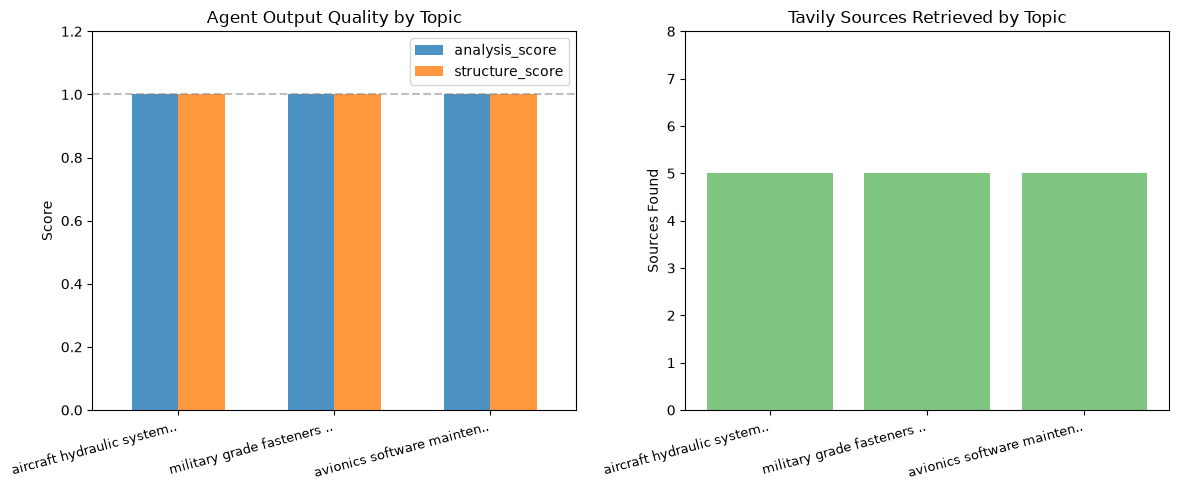

In [32]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
# shorten topics for readability
short_topics = [t[:25] + ".." for t in eval_df['topic']]
# analysis vs structure cores
x = range(len(eval_df))
width = 0.35

eval_df[["analysis_score", "structure_score"]].plot(
    kind="bar",
    ax=axes[0],
    color=["tab:blue", "tab:orange"],
    alpha=0.8,
    width=0.6
)
axes[0].set_xticklabels(short_topics, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.2)
axes[0].set_title("Agent Output Quality by Topic")
axes[0].legend()
axes[0].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)

# sources found per topic
axes[1].bar(short_topics, eval_df["sources_found"], color="tab:green", alpha=0.6)
axes[1].set_ylabel("Sources Found")
axes[1].set_title("Tavily Sources Retrieved by Topic")
axes[1].set_xticklabels(short_topics, rotation=15, ha="right", fontsize=9)
axes[1].set_ylim(0, 8)

plt.tight_layout()
plt.savefig("agent_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()